# Sentiment Analysis

## Introduction

So far, all of the analysis we've done has been pretty generic - looking at counts, creating scatter plots, etc. These techniques could be applied to numeric data as well.

When it comes to text data, there are a few popular techniques that we'll be going through in the next few notebooks, starting with sentiment analysis. A few key points to remember with sentiment analysis.

1. **TextBlob Module:** Linguistic researchers have labeled the sentiment of words based on their domain expertise. Sentiment of words can vary based on where it is in a sentence. The TextBlob module allows us to take advantage of these labels.
2. **Sentiment Labels:** Each word in a corpus is labeled in terms of polarity and subjectivity (there are more labels as well, but we're going to ignore them for now). A corpus' sentiment is the average of these.
   * **Polarity**: How positive or negative a word is. -1 is very negative. +1 is very positive.
   * **Subjectivity**: How subjective, or opinionated a word is. 0 is fact. +1 is very much an opinion.

For more info on how TextBlob coded up its [sentiment function](https://planspace.org/20150607-textblob_sentiment/).

Let's take a look at the sentiment of the various transcripts, both overall and throughout the comedy routine.

## Sentiment of Routine

In [1]:
# We'll start by reading in the corpus, which preserves word order
import pandas as pd

data = pd.read_pickle('corpus.pkl')
data

,transcript,full_name
blackwidow,Following the events of Captain America: Civ...,Spider-man: No Way Home
eternals,"The saga of the Eternals, a race of immortal...",Eternals
joker,CLASSIC SCENE Arthur is invited to appear on...,Wonder Woman
justiceleague,Determined to ensure Superman’s ultimate sac...,Joker
shangchi,Shang-Chi is a young man who is in denial ab...,Justice League (Jack Snyder)
spiderman,Peter Parker’s secret identity is revealed t...,Shang Chi and the Legend of the Ten Rings
venom,"In 1996, a young Cletus Kasady watches helpl...",Venom: Let There be Carnage
wonderwoman,"As a young girl, Diana Prince participates i...",Black Widow


In [2]:
# Create quick lambda functions to find the polarity and subjectivity of each movie
# Terminal / Anaconda Navigator: conda install -c conda-forge textblob
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

data['polarity'] = data['transcript'].apply(pol)
data['subjectivity'] = data['transcript'].apply(sub)
data

,transcript,full_name,polarity,subjectivity
blackwidow,Following the events of Captain America: Civ...,Spider-man: No Way Home,0.084278,0.455069
eternals,"The saga of the Eternals, a race of immortal...",Eternals,0.111316,0.534612
joker,CLASSIC SCENE Arthur is invited to appear on...,Wonder Woman,-0.088233,0.534075
justiceleague,Determined to ensure Superman’s ultimate sac...,Joker,0.086409,0.492534
shangchi,Shang-Chi is a young man who is in denial ab...,Justice League (Jack Snyder),0.061186,0.508129
spiderman,Peter Parker’s secret identity is revealed t...,Shang Chi and the Legend of the Ten Rings,0.128462,0.530948
venom,"In 1996, a young Cletus Kasady watches helpl...",Venom: Let There be Carnage,0.098064,0.557737
wonderwoman,"As a young girl, Diana Prince participates i...",Black Widow,0.175318,0.542946


C:\Users\DC ACER\AppData\Local\Temp\ipykernel_12048\3302106809.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(x+.001, y+.001, data['full_name'][index], fontsize=10)


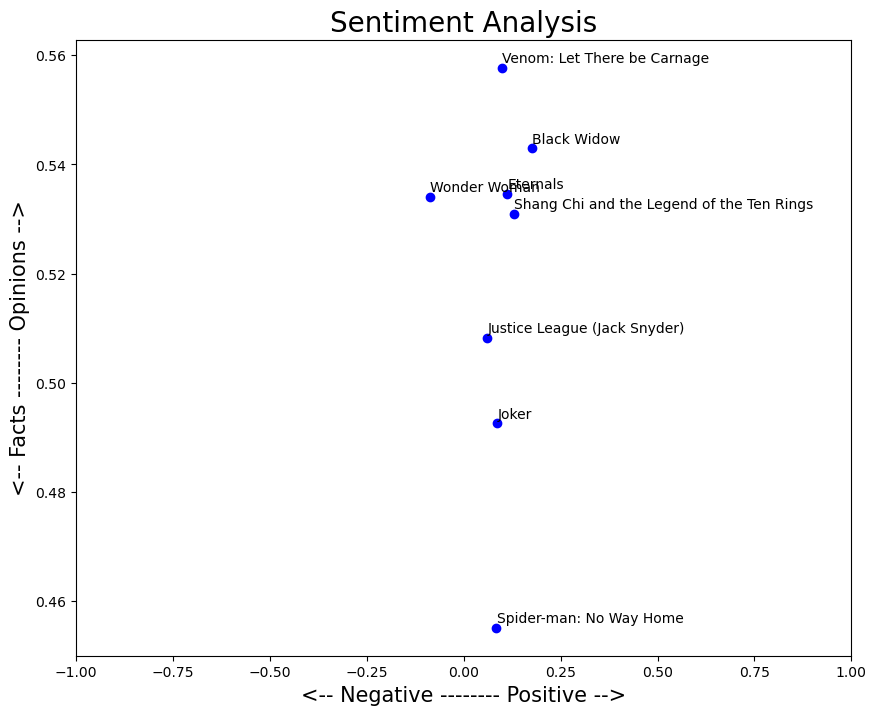

In [5]:
# Let's plot the results
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 8]

for index, movie in enumerate(data.index):
    x = data.polarity.loc[movie]
    y = data.subjectivity.loc[movie]
    plt.scatter(x, y, color='blue')
    plt.text(x+.001, y+.001, data['full_name'][index], fontsize=10)
    plt.xlim(-1, 1) 
    
plt.title('Sentiment Analysis', fontsize=20)
plt.xlabel('<-- Negative -------- Positive -->', fontsize=15)
plt.ylabel('<-- Facts -------- Opinions -->', fontsize=15)

plt.show()

## Sentiment of Routine Over Time

Instead of looking at the overall sentiment, let's see if there's anything interesting about the sentiment over time throughout each routine.

In [3]:
# Split each movie into 10 parts
import numpy as np
import math

def split_text(text, n=10):
    '''Takes in a string of text and splits into n equal parts, with a default of 10 equal parts.'''

    # Calculate length of text, the size of each chunk of text and the starting points of each chunk of text
    length = len(text)
    size = math.floor(length / n)
    start = np.arange(0, length, size)
    
    # Pull out equally sized pieces of text and put it into a list
    split_list = []
    for piece in range(n):
        split_list.append(text[start[piece]:start[piece]+size])
    return split_list

In [4]:
# Let's take a look at our data again
data

,transcript,full_name,polarity,subjectivity
blackwidow,Following the events of Captain America: Civ...,Spider-man: No Way Home,0.084278,0.455069
eternals,"The saga of the Eternals, a race of immortal...",Eternals,0.111316,0.534612
joker,CLASSIC SCENE Arthur is invited to appear on...,Wonder Woman,-0.088233,0.534075
justiceleague,Determined to ensure Superman’s ultimate sac...,Joker,0.086409,0.492534
shangchi,Shang-Chi is a young man who is in denial ab...,Justice League (Jack Snyder),0.061186,0.508129
spiderman,Peter Parker’s secret identity is revealed t...,Shang Chi and the Legend of the Ten Rings,0.128462,0.530948
venom,"In 1996, a young Cletus Kasady watches helpl...",Venom: Let There be Carnage,0.098064,0.557737
wonderwoman,"As a young girl, Diana Prince participates i...",Black Widow,0.175318,0.542946


In [7]:
list_pieces = []
for t in data.transcript:
    split = split_text(t)
    list_pieces.append(split)
    
list_pieces

[['  Following the events of Captain America: Civil War (2016), Natasha Romanoff finds herself on the run and forced to confront a dangerous conspiracy with ties to her past. Pursued by a force that will stop at nothing to bring her down, Romanoff must deal with her history as a spy and the broken relationships left in her wake long before she became an Avenger.  * * * (DRAMATIC MUSIC PLAYING) (BIRDS CHIRPING) (SOFT PIANO MUSIC PLAYING) (KIDS CHATTERING IN DISTANCE) OHIO, 1995 GIRL: Hey, Nat! (KIDS WHOOPING AND LAUGHING FAINTLY) (WHISTLES LONG NOTE) (YOUNG YELENA WHISTLES BACK) We’re both upside down. And I bet you’re gonna fall down first. No, you will. You can’t hold it much longer. (EXCLAIMING) (GRUNTS) Told you you’d fall down first. I told you! I told you! Told you so! Mommy! (SOBBING) What happened? She fell on her knee. Oh, you bump your knee? YOUNG YELENA: Mmm-hmm. Oh… Kiss it better. There we go. (SHUSHING)    Oh, come on, little one. Get up. You’re okay. Come on. You’re a bra

In [8]:
# The list has 10 elements, one for each transcript
len(list_pieces)

8

In [9]:
# Each transcript has been split into 10 pieces of text
len(list_pieces[0])

10

In [10]:
# Calculate the polarity for each piece of text

polarity_transcript = []
for lp in list_pieces:
    polarity_piece = []
    for p in lp:
        polarity_piece.append(TextBlob(p).sentiment.polarity)
    polarity_transcript.append(polarity_piece)
    
polarity_transcript

[[0.10490755170924662,
  0.006924483096495628,
  0.07219915097822074,
  0.08631030804943848,
  0.09020796590241034,
  0.17498630007558577,
  0.13535483257229836,
  0.04989915815941934,
  -0.01644965277777777,
  0.1021639702889703],
 [0.07859610431558108,
  0.1493672110717565,
  0.16744358650608648,
  0.21693159580145882,
  0.11806679431679432,
  0.01961876014610389,
  0.1141017316017316,
  0.1097387742975978,
  0.1044471085383914,
  0.06616730761148239],
 [0.05934343434343434,
  0.06060606060606061,
  -0.05476190476190477,
  0.19970238095238094,
  -0.28035714285714286,
  -0.10416666666666667,
  0.006249999999999978,
  -0.275,
  -0.35625,
  0.10727272727272727],
 [0.029075906808035717,
  0.053571290926391846,
  0.09445212558976597,
  0.16391321075496607,
  0.15131673881673874,
  0.05587272970085467,
  0.05620766077161426,
  -0.05136968766001028,
  0.2008723449653328,
  0.13471164920706205],
 [0.11046347171347175,
  0.007630587531155714,
  0.08161132848632849,
  0.11790105386416862,
  0.

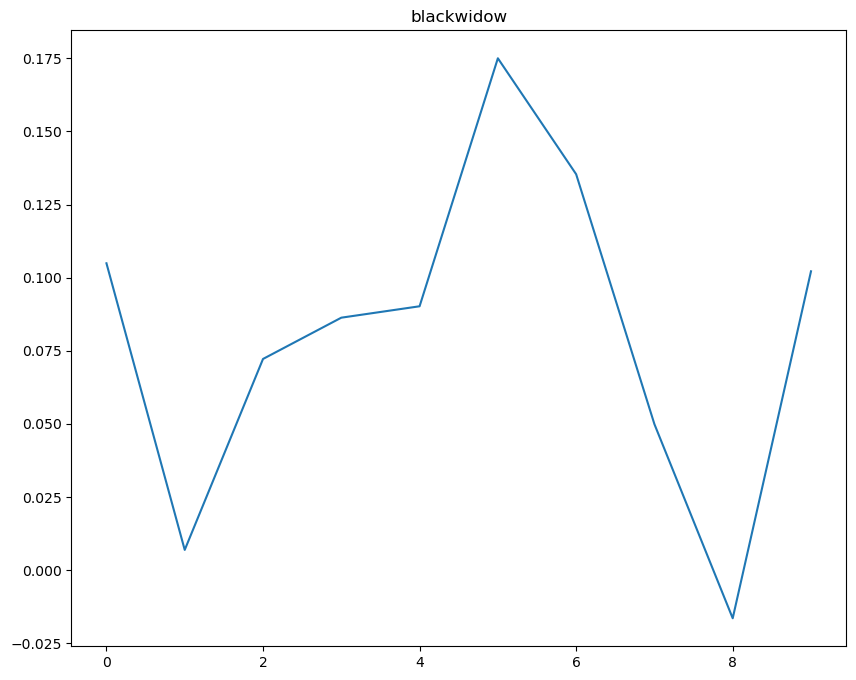

In [11]:
# Show the plot for one movie
plt.plot(polarity_transcript[0])
plt.title(data['full_name'].index[0])
plt.show()

In [ ]:
# Show the plot for all movies
plt.rcParams['figure.figsize'] = [16, 12]

for index, movie in enumerate(data.index):    
    plt.subplot(3, 4, index+1)
    plt.plot(polarity_transcript[index])
    plt.plot(np.arange(0,10), np.zeros(10))
    plt.title(data['full_name'][index])
    plt.ylim(ymin=-.2, ymax=.3)
    
plt.show()

Based on the patterns that we found using our plots, movies can be correlated with each other based on the visible similarities between the plot. 
* Spiderman, Eternals and Black Widow show a very similar graph
* Joker and Justice League also show a vaguely similar graph
* Venom shows that the movie regularly oscilates between opinions and facts